---
---
## Trabajo Práctico 6 - Test de Hipótesis
---
### Josefina Urquiza
---
---

La diabetes se diagnostica en base al nivel de glucosa en sangre. Según la base de datos de indios Pima la glucosa en sangre de personas sanas tiene una media $\mu_0 = 110.6\:mg/dl$ y una desviación estándar $\sigma_0 = 24.8\:mg/dl$. Para personas con diabetes la media es $\mu_1 = 142.3\:mg/dl$ y la desviación estándar $\sigma_1 = 29.6\:mg/dl$. Asumir que la glucosa en sangre para personas sanas y con diabetes sigue una distribución normal. Siguiendo las recomendaciones de la Organización Mundial de la Salud, a una persona se le diagnostica diabetes si su nivel de glucosa en sangre excede $126\:mg/dl$. Graficar las distribuciones de la glucosa en sangre para las hipótesis nula y alternativa. Indicar en la figura el valor crítico de la glucosa en sangre.

  Calcular la sensibilidad (poder) del test de glucosa en sangre, la probabilidad que
un paciente sano sea diagnosticado como diabético (falso positivo) y la
probabilidad que un paciente diabético sea diagnosticado como sano (falso negativo). Si la prevalencia de la diabetes es del $35\%$, calcular
aplicando el teorema de Bayes, la probabilidad que una persona con
un test positivo efectivamente tenga diabetes.

In [2]:
# Librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
print("Librerias ok")

Librerias ok


##### Parámetros para personas sanas

In [3]:
# Media
mu_PSanas = 110.6  #𝑚𝑔/𝑑𝑙
# Desviacion estandar
sigma_PSanas = 24.8  #𝑚𝑔/𝑑𝑙

##### Parámetros para personas con diabetes

In [4]:
#Media
mu_PDiabetes = 142.3 #𝑚𝑔/𝑑𝑙
# Desviacion estandar
sigma_PDiabetes = 29.6 #𝑚𝑔/𝑑𝑙

#### Segun la OMS, a una persona se le diagnostica diabetes si su nivel de glucosa en sangre excede el umbral de 126 𝑚𝑔/𝑑𝑙 

In [5]:
# Umbral de diagnóstico de diabetes
umbral = 126 #𝑚𝑔/𝑑𝑙

Se debe asumir que la glucosa en sangre para personas sanas y con diabetes sigue una distribución normal.

Entonces, para este test de glucosa en sangre
- hipótesis nula $(H_o)$: La persona no tiene diabetes. Por lo que se espera que el nivel de glucosa esté cerca de la media para personas sanas $mu PSanas$
- hipótesis alternativa  $(H_1)$ La persona tiene diabetes. En este caso, el nivel de glucosa estaría cerca de la media para personas con diabetes $mu PDiabetes$

Por lo que si el nivel de glucosa excede el valor umbral de 126 $𝑚𝑔/𝑑𝑙$ se rechaza $(H_o)$ en favor de $(H_1)$. Esto indica que la persona tiene diabetes

### 01.  Graficar las distribuciones de la glucosa en sangre para las hipótesis nula y alternativa. Indicar en la figura el valor crítico de la glucosa en sangre.

In [6]:
# semilla para garantizar resultados reproducibles
np.random.seed(42)

In [18]:
# Se genera un rango de valores de glucosa en sangre para graficar las distribuciones
valoresGlugosa = np.linspace(60, 220, 500)
#Mostrar algunos valores
valoresGlugosa[0:10]

array([60.        , 60.32064128, 60.64128257, 60.96192385, 61.28256513,
       61.60320641, 61.9238477 , 62.24448898, 62.56513026, 62.88577154])

Calcular las distribuciones de probabilidad para personas sanas y personas con diabetes usando la función de densidad de probabilidad normal (pdf).
$Comentario$ $de$ $clase$: Esto se puede hacer con norm.pdf de scipy o con numpy

In [73]:
#cometarios de la clase: El test de hipotesis a usar es el test de clasificacion

In [9]:
y_PSanas = norm.pdf(valoresGlugosa, mu_PSanas, sigma_PSanas)
y_PDiabetes = norm.pdf(valoresGlugosa, mu_PDiabetes, sigma_PDiabetes)

# Mostramos algunos valores
print("------     Personas sanas     ------")
print(y_PSanas[0:10])
print("------------------------------------------------------------------")
print("------     Personas con diabetes     ------")
print(y_PDiabetes[0:10])


------     Personas sanas     ------
[0.00200675 0.00206022 0.00211476 0.00217038 0.00222709 0.0022849
 0.00234382 0.00240386 0.00246502 0.00252732]
------------------------------------------------------------------
------     Personas con diabetes     ------
[0.00028244 0.00029106 0.00029991 0.00030899 0.0003183  0.00032786
 0.00033767 0.00034773 0.00035805 0.00036863]


### Graficar ambas distribuciones.

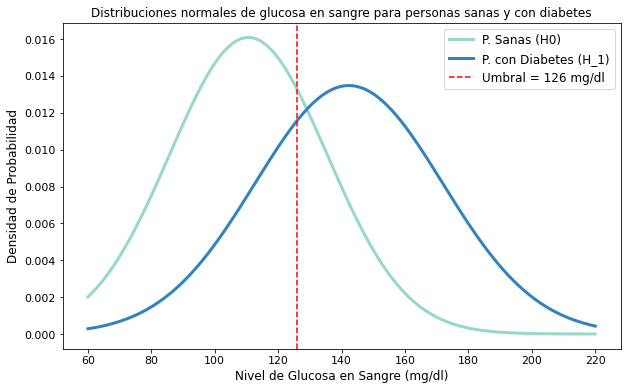

In [10]:
# Plot
#plt.figure(figsize=(8, 5), dpi=150) 
plt.figure(figsize=(10, 6))
#Hipótesis nula
plt.plot(valoresGlugosa, y_PSanas, label="P. Sanas (H0)", color="#99d8c9",linewidth=3)
#Hipótesis nulaalternativa
plt.plot(valoresGlugosa, y_PDiabetes, label="P. con Diabetes (H_1)", color="#3182bd",linewidth=3)

# Valor umbral
plt.axvline(x=umbral, color='red', linestyle='--', label=f'Umbral = {umbral} mg/dl')

# Titulos
plt.title("Distribuciones normales de glucosa en sangre para personas sanas y con diabetes")
plt.xlabel("Nivel de Glucosa en Sangre (mg/dl)", fontsize=12)
plt.ylabel("Densidad de Probabilidad", fontsize=12)
plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=11) 
# plot
plt.show()

### 02. Calcular la sensibilidad (poder) del test de glucosa en sangre.

Es decir, la probabilidad que un paciente sano sea diagnosticado como diabético (falso positivo) y la probabilidad que un paciente diabético sea diagnosticado como sano (falso negativo). 

La $Sensibilidad$ se calcula dividiendo el número de verdaderos positivos entre la suma de verdaderos positivos y falsos negativos

- Sensibilidad (Poder del test): Probabilidad de que un paciente con diabetes sea correctamente diagnosticado, es decir,
$P (Glucosa > 126 ∣ Diabetes)$.
 
- Falso positivo: Probabilidad de que un paciente sano sea incorrectamente diagnosticado con diabetes, es decir, $P(Glucosa > 126∣Sano)$.

- Falso negativo: Probabilidad de que un paciente con diabetes sea incorrectamente diagnosticado como sano, es decir, $P(Glucosa ≤ 126 ∣ Diabetes)$.

Entonces, en este ejemplo, el poder del test es la probabilidad que esté en la región crítica (rechazamos la hipótesis nula) 

Probabilidad de que una persona con diabetes tenga un nivel de glucosa superior a 126 mg/dl, es decir que sea tenga los valores de glucosa para ser diabetico y que efectivamente lo sea. Esto corresponde al area a la derecha del umbral en la distribución de personas con diabetes.

In [11]:
# Sensibilidad: P(glucosa > 126 | diabetes)
sensibilidad = 1 - norm.cdf(umbral, mu_PDiabetes, sigma_PDiabetes)

Probabilidad de que una persona sana tenga un nivel de glucosa superior a 126 mg/dl. Esto corresponde al área a la derecha del umbral en la distribución de personas sanas

In [13]:
# Falso positivo: P(glucosa > 126 | sano)
falso_positivo = 1 - norm.cdf(umbral, mu_PSanas, sigma_PSanas)

Probabilidad de que una persona con diabetes tenga un nivel de glucosa igual o inferior a 126 mg/dl. Esto corresponde al area a la izquierda del umbral en la distribución de personas con diabetes.

In [14]:
# Falso negativo: P(glucosa <= 126 | diabetes)
falso_negativo = norm.cdf(umbral, mu_PDiabetes, sigma_PDiabetes)

In [15]:
# Resultados
print(f"Sensibilidad: {sensibilidad:.3f}")
print(f"Probabilidad de falso positivo: {falso_positivo:.3f}")
print(f"Probabilidad de falso negativo: {falso_negativo:.3f}")

Sensibilidad: 0.709
Probabilidad de falso positivo: 0.267
Probabilidad de falso negativo: 0.291


## Teorema de Bayes

Para calcular la probabilidad de que una persona con un test positivo efectivamente tenga diabetes, se debe usar el Teorema de Bayes. Este teorema se utiliza para la probabilidad condicionales.

Este resultado depende de la sensibilidad (verdaderos positivos), la tasa de falsos positivos, y la prevalencia de la diabetes (35%).

- P(Diabetes)= 0.35: Prevalencia de diabetes (conocida).
- P(Positivo∣Diabetes): Sensibilidad del test, o probabilidad de dar positivo si se tiene diabetes. 
- P(Positivo∣Sano): Tasa de falsos positivos, o probabilidad de dar positivo si no se tiene diabetes.
- P(Sano)=1−P(Diabetes)=0.65: Probabilidad de que una persona no tenga diabetes.


$\ P(Diabetes∣Positivo)= \frac{P(Positivo) | P(Positivo ∣ Diabetes)}{P(Diabetes)}\$

 


In [16]:
# Prevalencia
prevalencia_diabetes = 0.35
prevalencia_sano = 1 - prevalencia_diabetes

In [17]:
# Probabilidad total de obtener un resultado positivo, P(Positivo)
prob_positivo = (sensibilidad * prevalencia_diabetes) + (falso_positivo * prevalencia_sano)

# Probabilidad de tener diabetes dado un resultado positivo, P(Diabetes | Positivo)
prob_diabetes_dado_positivo = (sensibilidad * prevalencia_diabetes) / prob_positivo

# Resultados
sensibilidad, falso_positivo, falso_negativo, prob_diabetes_dado_positivo

# Imprimir resultados
print(f"Sensibilidad: {sensibilidad:.3f}")
print(f"Falso positivo: {falso_positivo:.3f}")
print(f"Falso negativo: {falso_negativo:.3f}")
print(f"Probabilidad de tener diabetes dado un test positivo: {prob_diabetes_dado_positivo:.3f}")

Sensibilidad: 0.709
Falso positivo: 0.267
Falso negativo: 0.291
Probabilidad de tener diabetes dado un test positivo: 0.588


#### Conclusiones
Esta notebook muestra el calculo del test de hipotesis para diagnosticar diabetes basándonos en el nivel de glucosa en sangre. Donde los resultados indican:

- El parametro $Sensibilidad$ dice que el 70.9% de las personas con diabetes son correctamente identificadas por el test.
- Los resultados la probabilidad de $Falso$ $Positivo$ muestra que el 26.7% de las personas sanas podrian obtener un diagnostico positivo por error.
- Los resultados la probabilidad de $Falso$ $Negativo$ muestra que el test no detectaria a personas con diabetes en el 29.1% de los casos que sí son diabeticos.
- Por ultimo, si una persona obtiene un resultado positivo, hay un 58.8% de probabilidad de que efectivamente tenga diabetes.

Estos resultados son utiles ya que muestran la efectividad del test y los posibles errores en el diagnóstico a personas con diabetes.